In [1]:
import torch

In [2]:
import sys

assert sys.version_info >= (3,10)

In [3]:
from packaging.version import Version

assert Version(torch.__version__) >= Version("2.6.0")

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = 'cpu'

device

'cuda'

In [5]:
if device == "cpu":
    print("Neural nets can be very slow without a hardware accelerator.")
 

In [6]:
import matplotlib.pyplot as plt

plt.rc('font', size = 14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)


Vanishing/Exploding Gradients Problem

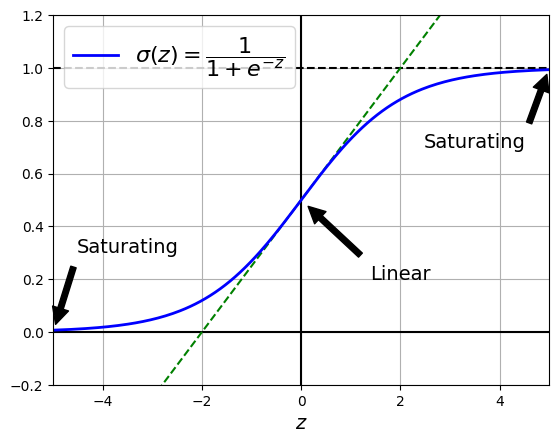

In [7]:
# extra code – this cell generates Figure 11–1

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
# plt.plot([-2.9, 2.9], [-.2, 1.2], 'r--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

plt.show()

In [8]:
import torch
import torch.nn as nn

layer = nn.Linear(40, 10)
layer.weight.data *= 6 ** 0.5
torch.zero_(layer.bias.data)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [9]:
layer = nn.Linear(40,10)
nn.init.kaiming_uniform_(layer.weight)
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

In [10]:
def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

model = nn.Sequential(nn.Linear(50, 40), nn.ReLU(), nn.Linear(40, 1), nn.ReLU())
model.apply(use_he_init)

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=1, bias=True)
  (3): ReLU()
)

In [11]:
model = nn.Sequential(nn.Linear(50, 40), nn.LeakyReLU(negative_slope=0.2))
model.apply(use_he_init)

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
)

Better Activation Functions

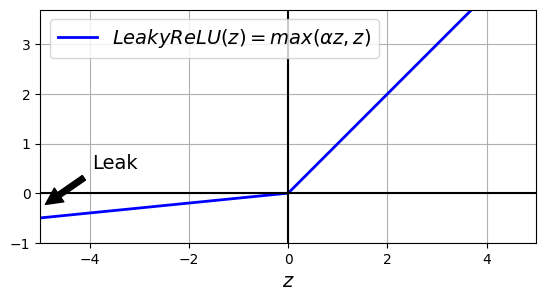

In [12]:
def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

In [13]:
torch.manual_seed(42)
alpha = 0.2
model = nn.Sequential(nn.Linear(50, 40), nn.LeakyReLU(negative_slope=alpha))
nn.init.kaiming_uniform_(model[0].weight, alpha, nonlinearity="leaky_relu")
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

ELU

In [14]:
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 40), nn.ELU())
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

Using SELU is straight forward:

In [15]:
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 40), nn.SELU())
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

GELU, Swish, SwiGLU, Mish, and Relu2

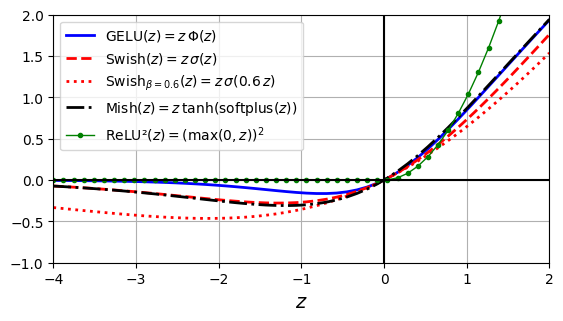

In [16]:
def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta= 1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

def relu_squared(z):
    return np.maximum(0, z)**2

z = np.linspace(-4,2,50)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "k-.", linewidth=2,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot(z, relu_squared(z), "g.-", linewidth=1,
         label=fr"ReLU²$(z) = (\max(0, z))^2$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=10)

plt.show()


SwiGLU

In [17]:
class SwiGLU(nn.Module):
    def __init__(self, beta=1.0):
        super().__init__()
        self.beta = beta

    def forward(self, x):
        z1, z2 = x.chunk(2, dim=-1)
        param_swish = z1 * torch.sigmoid(self.beta * z1)
        return param_swish

torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 2 * 40), SwiGLU(beta=0.2))
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

In [18]:
import torch.nn.functional as F

class ReLU2(nn.Module):
    def forward(self, x):
        return F.relu(x).square()

torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 40), ReLU2(),nn.Linear(40, 35), ReLU2())
# nn.init.kaiming_uniform_(model[0].weight)
# nn.init.kaiming_uniform_(model[2].weight)
# model(torch.rand(2, 50)).shape
model.apply(use_he_init)
model(torch.rand(2, 50)).shape


torch.Size([2, 35])

Batch Normalization

In [19]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(1 * 28 * 28),
    nn.Linear(1 * 28 * 28,300),
    nn.ReLU(),
    nn.BatchNorm1d(300),
    nn.Linear(300, 100),
    nn.ReLU(),
    nn.BatchNorm1d(100),
    nn.Linear(100,10)
)

In [20]:
dict(model[1].named_parameters()).keys()

dict_keys(['weight', 'bias'])

In [21]:
dict(model[1].named_buffers()).keys()

dict_keys(['running_mean', 'running_var', 'num_batches_tracked'])

In [22]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 *28, 300, bias=False),
    nn.BatchNorm1d(300),
    nn.ReLU(),
    nn.Linear(300, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 10
    )
)

Layer Normalization


In [23]:
torch.manual_seed(42)
inputs  = torch.randn(32, 3, 100, 200)
layer_norm = nn.LayerNorm([100, 200])
result = layer_norm(inputs)

In [24]:
layer_norm = nn.LayerNorm([3, 100, 200])
result = layer_norm(inputs)

In [25]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name="Fashion-Mnist", as_frame=False)
X = torch.FloatTensor(fashion_mnist.data.reshape(-1, 1, 28,28) / 255.)
y = torch.from_numpy(fashion_mnist.target.astype(int))
in_B = (y==0) | (y == 2)
X_A, y_A = X[~in_B], y[~in_B]
y_A = torch.maximum(y_A - 2, torch.tensor(0))
X_B, y_B = X[in_B], (y[in_B] == 2).to(dtype=torch.float32).view(-1,1)

train_set_A = TensorDataset(X_A[:-7_000], y_A[:-7000])
valid_set_A = TensorDataset(X_A[-7_000:-5_000], y_A[-7_000:-5_000])
test_set_A = TensorDataset(X_A[-5000:], y_A[-5000:])
train_set_B = TensorDataset(X_B[:20], y_B[:20])
valid_set_B = TensorDataset(X_B[20:5000], y_B[20:5000])
test_set_B  = TensorDataset(X_B[5_000:], y_B[5_000:])

train_loader_A = DataLoader(train_set_A, batch_size=32, shuffle=True)
valid_loader_A = DataLoader(valid_set_A, batch_size=32)
test_loader_A = DataLoader(test_set_A, batch_size=32)
train_loader_B = DataLoader(train_set_B, batch_size=32, shuffle=True)
valid_loader_B = DataLoader(valid_set_B, batch_size=32)
test_loader_B = DataLoader(test_set_B, batch_size=32)


In [26]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader,
          valid_loader, n_epochs):
    history = {"train_losses": [],
               "train_metrics": [],
               "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss/ len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs},"
              f"train losss: {history['train_losses'][-1]:.4f},"
              f"train metric: {history["train_metrics"][-1]:.4f}"
              f"valid metric: {history["valid_metrics"][-1]:.4f}")
    return history


Let' defin our first model for task A:


In [27]:
torch.manual_seed(42)

model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100,8)
)
model_A = model_A.to(device)

In [28]:
model_A.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=8, bias=True)
)

In [29]:
n_epochs = 20
optimizer = torch.optim.SGD(model_A.parameters(), lr=0.005, momentum=0)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=8).to(device)
histroy_A = train(model_A, optimizer, xentropy, accuracy,
train_loader_A, valid_loader_A, n_epochs)

Epoch 1/20,train losss: 0.5861,train metric: 0.8088valid metric: 0.8295
Epoch 2/20,train losss: 0.3347,train metric: 0.8847valid metric: 0.8840
Epoch 3/20,train losss: 0.2938,train metric: 0.8978valid metric: 0.8980
Epoch 4/20,train losss: 0.2717,train metric: 0.9057valid metric: 0.8275
Epoch 5/20,train losss: 0.2566,train metric: 0.9109valid metric: 0.8830
Epoch 6/20,train losss: 0.2437,train metric: 0.9154valid metric: 0.8955
Epoch 7/20,train losss: 0.2326,train metric: 0.9201valid metric: 0.8835
Epoch 8/20,train losss: 0.2249,train metric: 0.9224valid metric: 0.9115
Epoch 9/20,train losss: 0.2174,train metric: 0.9246valid metric: 0.9010
Epoch 10/20,train losss: 0.2098,train metric: 0.9267valid metric: 0.9010
Epoch 11/20,train losss: 0.2049,train metric: 0.9303valid metric: 0.9150
Epoch 12/20,train losss: 0.1993,train metric: 0.9300valid metric: 0.8950
Epoch 13/20,train losss: 0.1945,train metric: 0.9325valid metric: 0.9165
Epoch 14/20,train losss: 0.1896,train metric: 0.9335valid me

In [30]:
torch.manual_seed(42)

model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100,100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
).to(device)

In [31]:
model_B.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=1, bias=True)
)

In [32]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B.parameters(),lr=0.005,momentum=0)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
histroy_B = train(model_B, optimizer, xentropy, accuracy,
                  train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20,train losss: 0.9138,train metric: 0.6000valid metric: 0.4970
Epoch 2/20,train losss: 0.8160,train metric: 0.6000valid metric: 0.4970
Epoch 3/20,train losss: 0.7372,train metric: 0.6000valid metric: 0.4970
Epoch 4/20,train losss: 0.6738,train metric: 0.6000valid metric: 0.4970
Epoch 5/20,train losss: 0.6205,train metric: 0.6000valid metric: 0.4974
Epoch 6/20,train losss: 0.5771,train metric: 0.6000valid metric: 0.5008
Epoch 7/20,train losss: 0.5433,train metric: 0.6000valid metric: 0.5193
Epoch 8/20,train losss: 0.5176,train metric: 0.6000valid metric: 0.5520
Epoch 9/20,train losss: 0.4966,train metric: 0.7000valid metric: 0.5896
Epoch 10/20,train losss: 0.4785,train metric: 0.7500valid metric: 0.6189
Epoch 11/20,train losss: 0.4632,train metric: 0.8500valid metric: 0.6578
Epoch 12/20,train losss: 0.4499,train metric: 0.9000valid metric: 0.6855
Epoch 13/20,train losss: 0.4378,train metric: 0.9000valid metric: 0.7129
Epoch 14/20,train losss: 0.4270,train metric: 0.9000valid me

In [33]:
evaluate_tm(model_B, test_loader_B, accuracy)

tensor(0.8180, device='cuda:0')

In [46]:
import copy

torch.manual_seed(42)
reused_layers = copy.deepcopy(model_A[:-1])
model_B_on_A = nn.Sequential(
    *reused_layers,
    nn.Linear(100, 1)
).to(device)

In [47]:
for layer in model_B_on_A[:-1]:
    for param in layer.parameters():
        param.requires_grad = False

In [48]:
n_epochs = 10
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005, momentum=0)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
train_loader_B, valid_loader_B, n_epochs)

Epoch 1/10,train losss: 1.1642,train metric: 0.4000valid metric: 0.4888
Epoch 2/10,train losss: 0.9592,train metric: 0.4000valid metric: 0.4267
Epoch 3/10,train losss: 0.8422,train metric: 0.4000valid metric: 0.2908
Epoch 4/10,train losss: 0.7785,train metric: 0.2500valid metric: 0.2548
Epoch 5/10,train losss: 0.7398,train metric: 0.2000valid metric: 0.3359
Epoch 6/10,train losss: 0.7118,train metric: 0.4000valid metric: 0.4365
Epoch 7/10,train losss: 0.6885,train metric: 0.4500valid metric: 0.4940
Epoch 8/10,train losss: 0.6677,train metric: 0.6000valid metric: 0.5243
Epoch 9/10,train losss: 0.6484,train metric: 0.6000valid metric: 0.5496
Epoch 10/10,train losss: 0.6302,train metric: 0.6000valid metric: 0.5775


In [49]:
for layer in model_B_on_A[3:]:
    for param in layer.parameters():
        param.requires_grad = True

In [50]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005, momentum=0)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20,train losss: 0.6130,train metric: 0.6000valid metric: 0.6253
Epoch 2/20,train losss: 0.5899,train metric: 0.7000valid metric: 0.6781
Epoch 3/20,train losss: 0.5683,train metric: 0.8000valid metric: 0.7305
Epoch 4/20,train losss: 0.5480,train metric: 0.8500valid metric: 0.7693
Epoch 5/20,train losss: 0.5290,train metric: 0.9000valid metric: 0.8046
Epoch 6/20,train losss: 0.5111,train metric: 0.9500valid metric: 0.8281
Epoch 7/20,train losss: 0.4943,train metric: 0.9500valid metric: 0.8478
Epoch 8/20,train losss: 0.4785,train metric: 0.9500valid metric: 0.8631
Epoch 9/20,train losss: 0.4637,train metric: 0.9500valid metric: 0.8745
Epoch 10/20,train losss: 0.4497,train metric: 0.9500valid metric: 0.8825
Epoch 11/20,train losss: 0.4365,train metric: 0.9500valid metric: 0.8910
Epoch 12/20,train losss: 0.4240,train metric: 0.9500valid metric: 0.8960
Epoch 13/20,train losss: 0.4122,train metric: 0.9500valid metric: 0.9016
Epoch 14/20,train losss: 0.4010,train metric: 0.9500valid me

Faster Optimizers

In [57]:
train_set = TensorDataset(X[:55_000], y[:55_000])
valid_set = TensorDataset(X[55000:60_000], y[55_000:60_000])
test_set = TensorDataset(X[60_000:], y[60_000:])

def build_model(seed=42):
    torch.manual_seed(seed)
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 10),
    ).to(device)
    model.apply(use_he_init)
    return model

def test_optimizer(model, optimizer, n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    history = train(model, optimizer, xentropy, accuracy.to(device),
    train_loader, valid_loader, n_epochs)

    return history, evaluate_tm(model, test_loader, accuracy)


Momentum Optimization

In [58]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
history_sgd, acc_sgd = test_optimizer(model, optimizer)

Epoch 1/10,train losss: 0.5666,train metric: 0.7987valid metric: 0.8480
Epoch 2/10,train losss: 0.4090,train metric: 0.8522valid metric: 0.8526
Epoch 3/10,train losss: 0.3704,train metric: 0.8660valid metric: 0.8654
Epoch 4/10,train losss: 0.3442,train metric: 0.8743valid metric: 0.8698
Epoch 5/10,train losss: 0.3255,train metric: 0.8814valid metric: 0.8710
Epoch 6/10,train losss: 0.3117,train metric: 0.8845valid metric: 0.8758
Epoch 7/10,train losss: 0.2998,train metric: 0.8895valid metric: 0.8624
Epoch 8/10,train losss: 0.2870,train metric: 0.8944valid metric: 0.8774
Epoch 9/10,train losss: 0.2765,train metric: 0.8965valid metric: 0.8762
Epoch 10/10,train losss: 0.2683,train metric: 0.9004valid metric: 0.8576


Nesterov Accelerated Gradient

In [60]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, nesterov=True, lr=0.05)
history_nesterov, acc_nesterov = test_optimizer(model, optimizer)

Epoch 1/10,train losss: 0.5295,train metric: 0.8069valid metric: 0.8442
Epoch 2/10,train losss: 0.4248,train metric: 0.8469valid metric: 0.8418
Epoch 3/10,train losss: 0.3923,train metric: 0.8588valid metric: 0.8556
Epoch 4/10,train losss: 0.3760,train metric: 0.8642valid metric: 0.8658
Epoch 5/10,train losss: 0.3663,train metric: 0.8683valid metric: 0.8576
Epoch 6/10,train losss: 0.3533,train metric: 0.8718valid metric: 0.8588
Epoch 7/10,train losss: 0.3445,train metric: 0.8752valid metric: 0.8552
Epoch 8/10,train losss: 0.3399,train metric: 0.8774valid metric: 0.8680
Epoch 9/10,train losss: 0.3281,train metric: 0.8809valid metric: 0.8722
Epoch 10/10,train losss: 0.3254,train metric: 0.8837valid metric: 0.8574


In [61]:
model = build_model()
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.05)
history_adagrad, acc_adagrad = test_optimizer(model, optimizer)

Epoch 1/10,train losss: 0.5376,train metric: 0.8156valid metric: 0.8558
Epoch 2/10,train losss: 0.3739,train metric: 0.8639valid metric: 0.8632
Epoch 3/10,train losss: 0.3449,train metric: 0.8743valid metric: 0.8696
Epoch 4/10,train losss: 0.3243,train metric: 0.8808valid metric: 0.8716
Epoch 5/10,train losss: 0.3104,train metric: 0.8865valid metric: 0.8728
Epoch 6/10,train losss: 0.3000,train metric: 0.8886valid metric: 0.8774
Epoch 7/10,train losss: 0.2905,train metric: 0.8928valid metric: 0.8734
Epoch 8/10,train losss: 0.2823,train metric: 0.8955valid metric: 0.8812
Epoch 9/10,train losss: 0.2746,train metric: 0.8969valid metric: 0.8828
Epoch 10/10,train losss: 0.2681,train metric: 0.9011valid metric: 0.8788


In [62]:
model= build_model()
optimizer = torch.optim.RMSprop(model.parameters(), alpha=0.9, lr=0.05)
history_rmsprop, acc_rmsprop = test_optimizer(model, optimizer)

Epoch 1/10,train losss: 2.0520,train metric: 0.3832valid metric: 0.3756
Epoch 2/10,train losss: 1.5048,train metric: 0.4095valid metric: 0.4132
Epoch 3/10,train losss: 1.4398,train metric: 0.4272valid metric: 0.4562
Epoch 4/10,train losss: 1.3743,train metric: 0.4395valid metric: 0.4510
Epoch 5/10,train losss: 1.4452,train metric: 0.4449valid metric: 0.4410
Epoch 6/10,train losss: 1.3141,train metric: 0.4881valid metric: 0.5416
Epoch 7/10,train losss: 1.2150,train metric: 0.5253valid metric: 0.5008
Epoch 8/10,train losss: 1.1894,train metric: 0.5326valid metric: 0.5290
Epoch 9/10,train losss: 1.2480,train metric: 0.5102valid metric: 0.4444
Epoch 10/10,train losss: 1.3758,train metric: 0.4420valid metric: 0.3522


In [63]:
# Adam Optimization

model = build_model()
optimizer = torch.optim.Adam(model.parameters(), betas =(0.9, 0.999), lr=0.05)
history_adam, acc_adam = test_optimizer(model, optimizer)

Epoch 1/10,train losss: 0.9835,train metric: 0.6397valid metric: 0.6422
Epoch 2/10,train losss: 1.2587,train metric: 0.4818valid metric: 0.5360
Epoch 3/10,train losss: 1.1370,train metric: 0.5212valid metric: 0.4916
Epoch 4/10,train losss: 1.1201,train metric: 0.5163valid metric: 0.5972
Epoch 5/10,train losss: 1.1283,train metric: 0.5287valid metric: 0.5934
Epoch 6/10,train losss: 1.1825,train metric: 0.5075valid metric: 0.3832
Epoch 7/10,train losss: 1.3006,train metric: 0.4517valid metric: 0.3846
Epoch 8/10,train losss: 1.2913,train metric: 0.4549valid metric: 0.4368
Epoch 9/10,train losss: 1.3148,train metric: 0.4310valid metric: 0.3778
Epoch 10/10,train losss: 1.2774,train metric: 0.4486valid metric: 0.4366


In [64]:
model = build_model()
optimizer = torch.optim.Adamax(model.parameters(), betas=(0.9, 0.999), lr =0.05)
histroy_adamax, acc_adamax = test_optimizer(model, optimizer)

Epoch 1/10,train losss: 0.6034,train metric: 0.7963valid metric: 0.8362
Epoch 2/10,train losss: 0.4669,train metric: 0.8356valid metric: 0.8382
Epoch 3/10,train losss: 0.4383,train metric: 0.8422valid metric: 0.8484
Epoch 4/10,train losss: 0.4162,train metric: 0.8512valid metric: 0.8474
Epoch 5/10,train losss: 0.4034,train metric: 0.8562valid metric: 0.8622
Epoch 6/10,train losss: 0.3928,train metric: 0.8597valid metric: 0.8602
Epoch 7/10,train losss: 0.3864,train metric: 0.8614valid metric: 0.8492
Epoch 8/10,train losss: 0.3778,train metric: 0.8636valid metric: 0.8462
Epoch 9/10,train losss: 0.3762,train metric: 0.8648valid metric: 0.8560
Epoch 10/10,train losss: 0.3708,train metric: 0.8670valid metric: 0.8556


In [65]:
model = build_model()
optimizer = torch.optim.NAdam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_nadam, acc_nadam = test_optimizer(model, optimizer)

Epoch 1/10,train losss: 1.8574,train metric: 0.2031valid metric: 0.1906
Epoch 2/10,train losss: 1.8872,train metric: 0.1809valid metric: 0.1044
Epoch 3/10,train losss: 2.3154,train metric: 0.1006valid metric: 0.1126
Epoch 4/10,train losss: 2.3077,train metric: 0.1033valid metric: 0.1102
Epoch 5/10,train losss: 2.2962,train metric: 0.1096valid metric: 0.1006
Epoch 6/10,train losss: 2.2741,train metric: 0.1154valid metric: 0.1164
Epoch 7/10,train losss: 1.8633,train metric: 0.1874valid metric: 0.1946
Epoch 8/10,train losss: 1.7995,train metric: 0.1970valid metric: 0.1978
Epoch 9/10,train losss: 1.7477,train metric: 0.2019valid metric: 0.1910
Epoch 10/10,train losss: 1.7229,train metric: 0.1977valid metric: 0.2056


In [66]:
model = build_model()
optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9, 0.999), lr=0.05, weight_decay=1e-5)
history_adamw, acc_adamw = test_optimizer(model, optimizer)

Epoch 1/10,train losss: 1.0567,train metric: 0.6066valid metric: 0.6382
Epoch 2/10,train losss: 1.1837,train metric: 0.5160valid metric: 0.4772
Epoch 3/10,train losss: 1.2165,train metric: 0.5075valid metric: 0.4918
Epoch 4/10,train losss: 1.3165,train metric: 0.4429valid metric: 0.3904
Epoch 5/10,train losss: 1.3792,train metric: 0.4276valid metric: 0.5094
Epoch 6/10,train losss: 1.2939,train metric: 0.4502valid metric: 0.3590
Epoch 7/10,train losss: 1.3786,train metric: 0.3775valid metric: 0.3694
Epoch 8/10,train losss: 1.4620,train metric: 0.3607valid metric: 0.2592
Epoch 9/10,train losss: 1.5093,train metric: 0.2975valid metric: 0.3058
Epoch 10/10,train losss: 1.4676,train metric: 0.3107valid metric: 0.3418


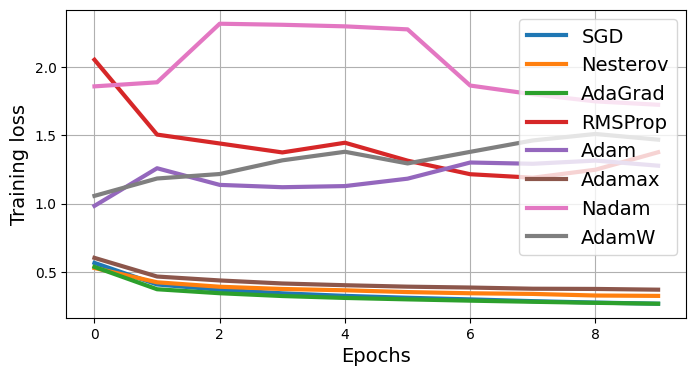

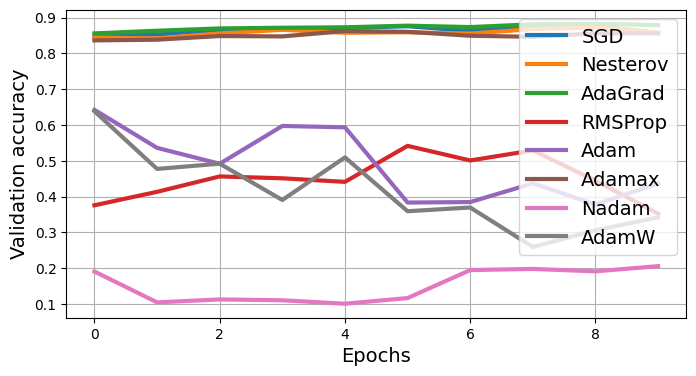

In [68]:
for plot in ("train_losses", "valid_metrics"):
    plt.figure(figsize=(8, 4))
    opt_names = "SGD Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip((history_sgd,history_nesterov, history_adagrad,
         history_rmsprop, history_adam, histroy_adamax, history_nadam,
         history_adamw), opt_names.split()):
        plt.plot(history[plot], label = opt_name, linewidth = 3)
    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"train_losses": "Training loss", "valid_metrics": "Validation accuracy"}[plot])
    plt.legend(loc="upper right")
    plt.show()

Learning Rate Scheduling

In [69]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
exp_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

In [70]:
def train_with_scheduler(model, optimizer, loss_fn, metric, train_loader,
                         valid_loader, n_epochs, scheduler):

    history = {"train_losses":[],
               "train_metrics": [],
               "valid_metrics": []}
    for epoch in range(n_epochs):
        losses = []
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(np.mean(losses))
        history["train_metrics"].append(metric.compute().item())
        val_metric  = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_metric)
        else:
            scheduler.step()
        print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
    return history

def test_scheduler(model, optimizer, scheduler, n_epochs=10, bathc_size=32):
    train_loader  = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train_with_scheduler(
        model, optimizer, xentropy, metric, train_loader, valid_loader,
        n_epochs, scheduler
    )
    return history, evaluate_tm(model, test_loader, metric)



In [71]:
history_exp, acc_exp = test_scheduler(model, optimizer, exp_scheduler)

Epoch 1/10, train loss: 0.5666, train metric: 0.7987, valid metric: 0.8480
Learning rate: 0.04500
Epoch 2/10, train loss: 0.4057, train metric: 0.8544, valid metric: 0.8522
Learning rate: 0.04050
Epoch 3/10, train loss: 0.3660, train metric: 0.8679, valid metric: 0.8646
Learning rate: 0.03645
Epoch 4/10, train loss: 0.3392, train metric: 0.8765, valid metric: 0.8710
Learning rate: 0.03281
Epoch 5/10, train loss: 0.3199, train metric: 0.8842, valid metric: 0.8752
Learning rate: 0.02952
Epoch 6/10, train loss: 0.3057, train metric: 0.8874, valid metric: 0.8782
Learning rate: 0.02657
Epoch 7/10, train loss: 0.2931, train metric: 0.8930, valid metric: 0.8758
Learning rate: 0.02391
Epoch 8/10, train loss: 0.2815, train metric: 0.8976, valid metric: 0.8798
Learning rate: 0.02152
Epoch 9/10, train loss: 0.2707, train metric: 0.9005, valid metric: 0.8820
Learning rate: 0.01937
Epoch 10/10, train loss: 0.2627, train metric: 0.9040, valid metric: 0.8776
Learning rate: 0.01743


In [73]:
model  = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.1)
history_perf, acc_perf = test_scheduler(model, optimizer, perf_scheduler)

Epoch 1/10, train loss: 0.5666, train metric: 0.7987, valid metric: 0.8480
Learning rate: 0.05000
Epoch 2/10, train loss: 0.4090, train metric: 0.8522, valid metric: 0.8526
Learning rate: 0.05000
Epoch 3/10, train loss: 0.3704, train metric: 0.8660, valid metric: 0.8654
Learning rate: 0.05000
Epoch 4/10, train loss: 0.3442, train metric: 0.8743, valid metric: 0.8698
Learning rate: 0.05000
Epoch 5/10, train loss: 0.3255, train metric: 0.8814, valid metric: 0.8710
Learning rate: 0.05000
Epoch 6/10, train loss: 0.3117, train metric: 0.8845, valid metric: 0.8758
Learning rate: 0.05000
Epoch 7/10, train loss: 0.2998, train metric: 0.8895, valid metric: 0.8624
Learning rate: 0.05000
Epoch 8/10, train loss: 0.2870, train metric: 0.8944, valid metric: 0.8774
Learning rate: 0.05000
Epoch 9/10, train loss: 0.2765, train metric: 0.8965, valid metric: 0.8762
Learning rate: 0.05000
Epoch 10/10, train loss: 0.2683, train metric: 0.9004, valid metric: 0.8576
Learning rate: 0.05000


In [76]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)

In [77]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lambda epoch: (min(epoch, 3) / 3) * (1.0 - 0.1) + 0.1)

In [90]:
# extra code
def train_with_warmup(model, optimizer, loss_fn, metric, train_loader,
                      valid_loader, n_epochs, warmup_scheduler, scheduler):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):

        warmup_scheduler.step()

        # extra code
        losses = []
        metric.reset()

        for X_batch, y_batch in train_loader:

            # extra code
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(np.mean(losses))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")

        if epoch >= 3:  # deactivate other scheduler(s) during warmup
            scheduler.step(val_metric)

        # extra code
        print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
    return history

def test_warmup_scheduler(model, optimizer, warmup_scheduler, scheduler,
                          n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train_with_warmup(
        model, optimizer, xentropy, metric, train_loader, valid_loader,
        n_epochs, warmup_scheduler, scheduler)
    return history, evaluate_tm(model, test_loader, metric)

In [91]:
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.1)
test_warmup_scheduler(model, optimizer, warmup_scheduler, perf_scheduler,
                         n_epochs=10, batch_size=32)

Epoch 1/10, train loss: 0.5849, train metric: 0.7956, valid metric: 0.8354
Learning rate: 0.02000
Epoch 2/10, train loss: 0.4333, train metric: 0.8454, valid metric: 0.8622
Learning rate: 0.02000
Epoch 3/10, train loss: 0.3812, train metric: 0.8606, valid metric: 0.8536
Learning rate: 0.02000
Epoch 4/10, train loss: 0.3500, train metric: 0.8731, valid metric: 0.8628
Learning rate: 0.05000
Epoch 5/10, train loss: 0.3303, train metric: 0.8785, valid metric: 0.8654
Learning rate: 0.05000
Epoch 6/10, train loss: 0.3158, train metric: 0.8843, valid metric: 0.8726
Learning rate: 0.05000
Epoch 7/10, train loss: 0.3009, train metric: 0.8890, valid metric: 0.8724
Learning rate: 0.05000
Epoch 8/10, train loss: 0.2916, train metric: 0.8922, valid metric: 0.8750
Learning rate: 0.05000
Epoch 9/10, train loss: 0.2800, train metric: 0.8972, valid metric: 0.8772
Learning rate: 0.05000
Epoch 10/10, train loss: 0.2723, train metric: 0.8985, valid metric: 0.8740
Learning rate: 0.05000


({'train_losses': [np.float64(0.5849282006023927),
   np.float64(0.4332894181974618),
   np.float64(0.38117246518324394),
   np.float64(0.34996367300090714),
   np.float64(0.33031828054392176),
   np.float64(0.31582062188243365),
   np.float64(0.3008653345740486),
   np.float64(0.2916060279428508),
   np.float64(0.28003741908924673),
   np.float64(0.2722889712040268)],
  'train_metrics': [0.7956363558769226,
   0.8453636169433594,
   0.8605999946594238,
   0.8730727434158325,
   0.8785454630851746,
   0.8842909336090088,
   0.8889999985694885,
   0.8921999931335449,
   0.8971636295318604,
   0.8985090851783752],
  'valid_metrics': [0.8353999853134155,
   0.8622000217437744,
   0.853600025177002,
   0.8628000020980835,
   0.8654000163078308,
   0.8726000189781189,
   0.8723999857902527,
   0.875,
   0.8772000074386597,
   0.8740000128746033]},
 tensor(0.8761, device='cuda:0'))

Avoiding Overfitting Through Regularization

l1 and l2 Regularization

In [92]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, weight_decay=1e-4)
history = test_optimizer(model, optimizer)

Epoch 1/10,train losss: 0.5673,train metric: 0.7975valid metric: 0.8488
Epoch 2/10,train losss: 0.4096,train metric: 0.8529valid metric: 0.8476
Epoch 3/10,train losss: 0.3719,train metric: 0.8663valid metric: 0.8646
Epoch 4/10,train losss: 0.3447,train metric: 0.8734valid metric: 0.8688
Epoch 5/10,train losss: 0.3253,train metric: 0.8814valid metric: 0.8716
Epoch 6/10,train losss: 0.3113,train metric: 0.8850valid metric: 0.8736
Epoch 7/10,train losss: 0.2999,train metric: 0.8888valid metric: 0.8668
Epoch 8/10,train losss: 0.2888,train metric: 0.8940valid metric: 0.8782
Epoch 9/10,train losss: 0.2786,train metric: 0.8953valid metric: 0.8798
Epoch 10/10,train losss: 0.2707,train metric: 0.9000valid metric: 0.8694


In [96]:
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()
optimizer =  torch.optim.SGD(model.parameters(), lr = 0.05)
params_to_regularize = [
    param for name, param in model.named_parameters()
    if not "bias" in name and not "bn" in name]
for epoch in range(n_epochs):
    total_loss = 0.0
    total_l2_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        main_loss = loss_fn(y_pred, y_batch)
        l2_loss = sum(param.pow(2.0).sum() for param in params_to_regularize)
        loss = main_loss + 1e-4 * l2_loss
        total_loss += loss.item()
        total_l2_loss += l2_loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}"
          f" – l2 loss: {total_l2_loss / len(train_loader):.3f}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – l2 loss: 439.362 – loss: 0.611
Epoch 2/3 – l2 loss: 455.103 – loss: 0.458
Epoch 3/3 – l2 loss: 462.887 – loss: 0.419


In [97]:
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code
params_to_regularize = [
    param for name, param in model.named_parameters()
    if not "bias" in name and not "bn" in name]
params_bias_and_bn = [
    param for name, param in model.named_parameters()
    if "bias" in name or "bn" in name]
optimizer = torch.optim.SGD([
    {"params": params_to_regularize, "weight_decay": 1e-4},
    {"params": params_bias_and_bn, "weight_decay": 0},
    ], lr=0.05)
for epoch in range(n_epochs):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – loss: 0.568
Epoch 2/3 – loss: 0.412
Epoch 3/3 – loss: 0.370


In [98]:
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
params_to_regularize = [
    param for name, param in model.named_parameters()
    if not "bias" in name and not "bn" in name]
for epoch in range(n_epochs):
    total_loss = 0.0
    total_l1_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        main_loss = loss_fn(y_pred, y_batch)
        l1_loss = sum(param.abs().sum() for param in params_to_regularize)
        loss = main_loss + 1e-4 * l1_loss
        total_loss += loss.item()
        total_l1_loss += l1_loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}"
          f" – l1 loss: {total_l1_loss / len(train_loader):.3f}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – l1 loss: 4516.938 – loss: 1.021
Epoch 2/3 – l1 loss: 3990.254 – loss: 0.817
Epoch 3/3 – l1 loss: 3513.451 – loss: 0.734


Dropout

In [100]:
torch.manual_seed(42)
model  = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(p=0.2), nn.Linear(28 * 28, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 10)
).to(device)
model.apply(use_he_init)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
history_dropout, acc_dropout = test_optimizer(model, optimizer, batch_size=32)

Epoch 1/10,train losss: 0.6750,train metric: 0.7534valid metric: 0.8348
Epoch 2/10,train losss: 0.5069,train metric: 0.8154valid metric: 0.8510
Epoch 3/10,train losss: 0.4734,train metric: 0.8280valid metric: 0.8622
Epoch 4/10,train losss: 0.4500,train metric: 0.8350valid metric: 0.8616
Epoch 5/10,train losss: 0.4326,train metric: 0.8428valid metric: 0.8582
Epoch 6/10,train losss: 0.4236,train metric: 0.8436valid metric: 0.8688
Epoch 7/10,train losss: 0.4138,train metric: 0.8474valid metric: 0.8720
Epoch 8/10,train losss: 0.4055,train metric: 0.8510valid metric: 0.8742
Epoch 9/10,train losss: 0.3963,train metric: 0.8523valid metric: 0.8728
Epoch 10/10,train losss: 0.3925,train metric: 0.8553valid metric: 0.8774


In [101]:
model.eval()
for module in model.modules():
    if isinstance(module, nn.Dropout):
        module.train()

X_new = torch.FloatTensor(fashion_mnist.data[:3].reshape(3, 1, 28, 28) / 255)
X_new = X_new.to(device)

torch.manual_seed(42)
with torch.no_grad():
    X_new_repeated = X_new.repeat_interleave(100, dim=0)
    y_logits_all = model(X_new_repeated).reshape(3, 100, 10)
    y_probas_all = torch.nn.functional.softmax(y_logits_all, dim=-1)
    y_probas = y_probas_all.mean(dim=1)

In [102]:
y_probas.round(decimals=2)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0200, 0.0000,
         0.9800],
        [0.9900, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0100, 0.0000, 0.0000,
         0.0000],
        [0.3800, 0.0300, 0.0300, 0.3700, 0.0400, 0.0000, 0.1500, 0.0000, 0.0000,
         0.0000]], device='cuda:0')

In [103]:
y_std = y_probas_all.std(dim=1)
y_std.round(decimals=2)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0300, 0.0000,
         0.0300],
        [0.0300, 0.0000, 0.0000, 0.0100, 0.0000, 0.0000, 0.0200, 0.0000, 0.0000,
         0.0000],
        [0.2000, 0.0300, 0.0300, 0.1800, 0.0600, 0.0000, 0.0700, 0.0000, 0.0100,
         0.0000]], device='cuda:0')

In [104]:
class McDropout(nn.Dropout):
    def forward(self, input):
        return F.dropout(input, self.p, training=True)

In [105]:
def mean_prediction(model, X, n_repeats):
    X_new_repeated = X_new.repeat_interleave(n_repeats, dim=0)
    y_logits = model(X_new_repeated)
    y_logits_all = y_logits.reshape(X.shape[0], n_repeats, *y_logits.shape[1:])
    y_probas_all = torch.nn.functional.softmax(y_logits_all, dim=-1)
    return y_probas_all.mean(dim=1)

In [106]:
with torch.no_grad():
  y_mean_pred = mean_prediction(model, X_new, 100)

y_mean_pred.round(decimals=2)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0200, 0.0000,
         0.9800],
        [0.9900, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0100, 0.0000, 0.0000,
         0.0000],
        [0.4000, 0.0200, 0.0300, 0.3700, 0.0300, 0.0000, 0.1400, 0.0000, 0.0000,
         0.0000]], device='cuda:0')